# Week 7 Lab Solutions: RNNs and LSTMs

In this Lab we'll see how RNNs and LSTMs are constructed as well as their behaviour.  The first part of the Lab relates to Tutorial Exercise 3.  The second part of the Lab involves an application of sequence models to a simple synthetic copy task.

It is strongly recommended that you run this notebook in Colab.



In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## PART 1. Plots for tutorial Exercise 2: Vanishing/exploding gradient for 1D linear RNN

1.0


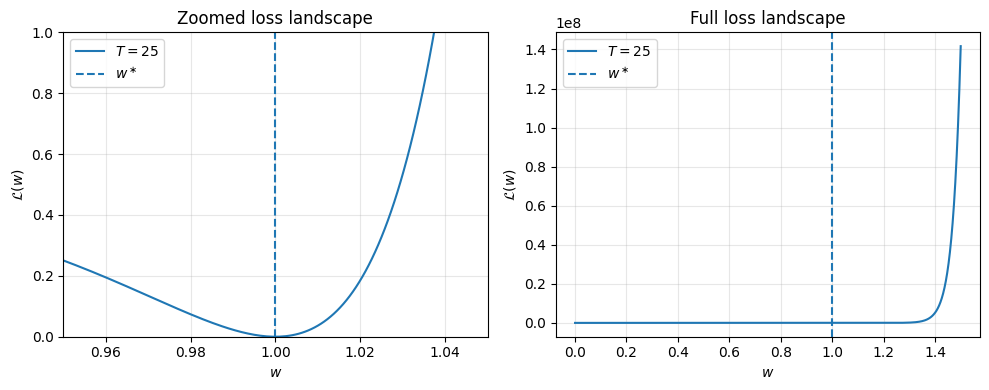

In [ ]:
# Fixed values
u = 1.0
x = 1.0
y = 1.0
T = 25

wstar = (y / (u * x)) ** (1 / (T - 1))
w = np.linspace(0, 1.5, 2000)
L = 0.5 * (u * x * w**(T - 1) - y)**2

#print(L[-10:])
print(wstar)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Left plot (zoomed)
ax[0].plot(w, L, label=rf"$T={T}$")
ax[0].axvline(wstar, linestyle="--", label=r"$w^\ast$")
ax[0].set_xlabel(r"$w$")
ax[0].set_ylabel(r"$\mathcal{L}(w)$")
ax[0].set_title("Zoomed loss landscape")
ax[0].set_xlim(0.95, 1.05)
ax[0].set_ylim(0, 1)
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Right plot (full view)
ax[1].plot(w, L, label=rf"$T={T}$")
ax[1].axvline(wstar, linestyle="--", label=r"$w^\ast$")
ax[1].set_xlabel(r"$w$")
ax[1].set_ylabel(r"$\mathcal{L}(w)$")
ax[1].set_title("Full loss landscape")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## PART 2. Synthetic copy task

In this part you will experiment with applying RNNs and LSTMs to a synthetic long-range dependency task often called a **copy task**. Each example (i.e. element of the training data) is a sequence with three parts:

1. a single **signal token** (one of the numbers 0–7) at the beginning,
2. a variable number of **blank/filler tokens**, (shown here as `_`),
3. a final **query token** (`8`) at the end.

The model must remember the first token across the delay (blank spaces) and, when it sees the query token, predict the original signal token.  In other words, the target output is the class label corresponding to the very first input symbol, not the filler tokens.  Of course it must do this without being explicitly programmed to do so, but must learn the rule from the training data.

For example, if the input sequence is

```
Input:
[3, _, _, _, _, _, 8,]
```

then the correct output is

```
Output:
3
```

The network must ignore the blank tokens, remember that the first token was **3**, and reproduce it when the query token appears.  The number of blank tokens can vary between examples.

For this lab, the only difference between the **short** and **long** copy tasks is the number of blank tokens between the first symbol and the query token. The short task requires the network to remember the signal for only a few timesteps, while the long task requires it to remember the signal for many more. Because there are eight possible signal tokens (0–7), a model that is simply guessing would achieve an accuracy of approximately **12.5% (1/8)**.

The purpose of the experiment is to demonstrate that a vanilla RNN can usually solve the short copy task, but often fails on the long copy task because the information about the first token is gradually lost as it propagates through many recurrent steps.

Here we use **PyTorch Adam** for optimisation, but the recurrent computation itself is coded from scratch instead of using `nn.RNN` or `nn.LSTM`.



## Runtime note

The default settings below are designed for relatively quick runtime (should not be more than a few mins).

For an even quicker run, set `FAST_DEMO = True`, which might result in some loss of accuracy.

In [ ]:
np.random.seed(42)
torch.manual_seed(42)
torch.use_deterministic_algorithms(False)

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

## 1. Define function to generate synthetic data

Below we define a function that generates a synthetic dataset. Each input sequence begins with a randomly chosen **signal token** (an integer from 0 to 7), followed by a specified number of **blank tokens** (`0`), and ends with a special **query token** (`8`). The target output is simply the original signal token. To solve the task, the model must remember the first token until it encounters the query token. Increasing the `delay` increases the length of time the information must be retained, making the task progressively more difficult.


In [ ]:
def generate_memory_task(n_samples, delay, vocab_size=8, seed=42):

    #Generate sequences where the last token must match the first token.
    #Input:  [signal, zeros * delay, query]
    #Target: predict the signal value at the query position.
    #If seed is None, new random examples are generated each call.

    if seed is not None:
        torch.manual_seed(seed)
    signals = torch.randint(0, vocab_size, (n_samples,), dtype=torch.long) #generate n_sample random integers between 0 and vocab_size-1
    X = torch.zeros(n_samples, delay + 2, dtype=torch.long)
    X[:, 0] = signals
    X[:, -1] = vocab_size  # special query token at final position
    y = signals
    return X, y

In [ ]:
# Generate a single example to check whether function is correct.
X, y = generate_memory_task(n_samples=1, delay=5, seed=42)

print(X.shape)
print("Input sequence :", X[0].tolist())
print("Target output  :", y[0].item())

torch.Size([1, 7])
Input sequence : [6, 0, 0, 0, 0, 0, 8]
Target output  : 6


## 2. Construct a simple RNN from scratch

### **Exercise :** What is the structure of the RNN corresponding to the code below?

**ANSWER**:
Given an input sequence of token indices

$$
x^{(1)}, x^{(2)}, \ldots, x^{(T)},
$$

the embedding layer first maps each token to a dense vector

$$
e^{(t)} = E[x^{(t)}],
$$

where $E \in \mathbb{R}^{(|V|+1)\times d}$ is the embedding matrix.  The hidden state is initialised as
$
h^{(0)} = 0,
$
and is updated recursively according to

$$
h^{(t)}
=
\tanh\!\left(
W_{xh}e^{(t)}
+
W_{hh}h^{(t-1)}
+
b_h
\right),
\qquad t=1,\ldots,T,
$$

where

- $W_{xh}\in\mathbb{R}^{m\times d}$ is the input-to-hidden weight matrix,
- $W_{hh}\in\mathbb{R}^{m\times m}$ is the recurrent weight matrix,
- $b_h\in\mathbb{R}^{m}$ is the bias vector.

After processing the entire sequence, only the final hidden state is used for classification. The output logits are
$$ z = W_y h^{(T)} + b_y, $$
and the predicted class probabilities are
$$
\widehat{y} = \operatorname{softmax}(z).
$$

Thus the complete model is

$$
\begin{aligned}
e^{(t)} &= E[x^{(t)}], \\
h^{(0)} &= 0, \\
h^{(t)}
&=
\tanh\!\left( W_{xh}e^{(t)} + W_{hh}h^{(t-1)} + b_h \right), \qquad t=1,\ldots,T,\\
z &= W_y h^{(T)} + b_y,\\
\widehat{y} &= \operatorname{softmax}(z).
\end{aligned}
$$
This is sometimes referred to as a many to one RNN because only the final hidden state is used for the output.

**Important**: The softmax is not directly applied within the SimpleRNN class.

In [ ]:
class SimpleRNN(nn.Module):
    # A vanilla Elman RNN written explicitly in PyTorch.

    def __init__(self, vocab_size, embed_dim, hidden_size, n_classes):
        super().__init__() # Initialise the parent nn.Module class
        self.embed = nn.Embedding(vocab_size + 1, embed_dim)  # Learn an embedding vector for each input token (+1 for query token)
        self.Wxh = nn.Parameter(torch.randn(hidden_size, embed_dim) * 0.1)   # Input-to-hidden weight matrix (small random initialisation)

        self.Whh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)  # Hidden-to-hidden (recurrent) weight matrix
        self.bh = nn.Parameter(torch.zeros(hidden_size))  # Bias vector for the hidden layer
        self.classifier = nn.Linear(hidden_size, n_classes) # Linear layer mapping hidden state to output logits
        self.hidden_size = hidden_size  # Store hidden state dimension for later use

    def forward(self, x, return_hiddens=False): # Define the forward pass through the network

        # x: LongTensor of shape (batch, seq_len)
        #returns logits for the final timestep.
        #If return_hiddens=True, also returns the list of hidden states.

        emb = self.embed(x)  # Convert token indices into embedding vectors (batch, seq_len, embed_dim)
        batch_size, seq_len, _ = emb.shape  # Extract batch size and sequence length from tensor shape

        h = torch.zeros(batch_size, self.hidden_size, device=x.device, dtype=emb.dtype) # Initialise hidden state to zeros
        hiddens = []

        for t in range(seq_len):
            x_t = emb[:, t, :]  # Extract embeddings for timestep t
            h = torch.tanh(x_t @ self.Wxh.T + h @ self.Whh.T + self.bh) #evaluate RNN on current state
            if return_hiddens:
                h.retain_grad()
                hiddens.append(h)

        logits = self.classifier(h) # Convert final hidden state into class logits (i.e. log odds, can be positive or negative.)
        if return_hiddens:
            return logits, hiddens  # Return hidden states if requested
        return logits  # Otherwise return only the output logits

## 3. Construct LSTM from scratch

The LSTM below uses the same PyTorch training loop and optimiser as the RNN, but the recurrent computation itself is written explicitly. It matches the usual `nn.LSTM` input/output convention for a single-layer, batch-first LSTM:

`output, (h_n, c_n) = lstm(x, hx=None)`


In [ ]:
class ScratchLSTM(nn.Module):

    # A single-layer, batch-first LSTM implemented from scratch.

    #Shapes:
    #    x:   (batch, seq_len, input_size)
    #    h_0: (1, batch, hidden_size)
    #    c_0: (1, batch, hidden_size)
    #    output: (batch, seq_len, hidden_size)
    #    h_n: (1, batch, hidden_size)
    #    c_n: (1, batch, hidden_size)

    def __init__(self, input_size, hidden_size, batch_first=True):
        super().__init__()  # Initialize parent nn.Module
        self.input_size = input_size   # Store input dimension
        self.hidden_size = hidden_size
        self.batch_first = batch_first   # Sets shape of the tensor with batch size first,

        # Parameters follow the same gate order as PyTorch: i, f, g, o
        self.weight_ih = nn.Parameter(torch.empty(4 * hidden_size, input_size)) # Input-to-gate weights (i.e. stacked matrix of the 4 weight matrices in front of input)
        self.weight_hh = nn.Parameter(torch.empty(4 * hidden_size, hidden_size))  # Hidden-to-gate weights
        self.bias_ih = nn.Parameter(torch.zeros(4 * hidden_size)) # Input bias  (note this separately provides a bias corresponding to the input)
        self.bias_hh = nn.Parameter(torch.zeros(4 * hidden_size))  # Hidden bias

        self.reset_parameters() # Initialize parameters

    ####### THIS IS THE PART THAT MUST BE MODIFIED IN EXERCISE 2. #######
    def reset_parameters(self):
        # Similar spirit to PyTorch's default initialization
        stdv = 1.0 / math.sqrt(self.hidden_size)  # Compute initialization range
        with torch.no_grad():
            self.weight_ih.uniform_(-stdv, stdv)   # Randomize input weights
            self.weight_hh.uniform_(-stdv, stdv)  # Randomize recurrent weights

            #ORIGINAL FORM:
            #self.bias_ih.uniform_(-stdv, stdv)
            #self.bias_hh.uniform_(-stdv, stdv)

            #EXERCISE 2. VERSION:
            # Initialise the forget gate bias
            self.bias_ih[self.hidden_size:2*self.hidden_size].fill_(0) #Modify both ih and hh because bias is separately applied to hidden state and input in the gate, even though their sum is just a single bias term.  Change value in bracket to change initialisation.  Note indexing: self.hidden_size:2*self.hidden_size refers specifically to the forget bias.
            self.bias_hh[self.hidden_size:2*self.hidden_size].fill_(0)

    def _forward_impl(self, x, hx=None, collect_hiddens=False):
        if x.dim() != 3:
            raise ValueError(f"Expected input of shape (batch, seq_len, input_size), got {tuple(x.shape)}")
        if not self.batch_first:
            x = x.transpose(0, 1)

        batch_size, seq_len, _ = x.shape
        device = x.device
        dtype = x.dtype

        if hx is None:
            h_t = torch.zeros(batch_size, self.hidden_size, device=device, dtype=dtype)
            c_t = torch.zeros(batch_size, self.hidden_size, device=device, dtype=dtype)
        else:
            h_0, c_0 = hx
            if h_0.dim() != 3 or c_0.dim() != 3:
                raise ValueError("hx must be a tuple of tensors shaped (1, batch, hidden_size)")
            h_t = h_0.squeeze(0)  # Remove layer dimension
            c_t = c_0.squeeze(0)

        outputs = []
        hiddens = []
        for t in range(seq_len):
            x_t = x[:, t, :]

            gates = (
                torch.matmul(x_t, self.weight_ih.t()) + self.bias_ih +  # Compute all four gates together
                torch.matmul(h_t, self.weight_hh.t()) + self.bias_hh
            )
            i_t, f_t, g_t, o_t = gates.chunk(4, dim=1)

            i_t = torch.sigmoid(i_t)
            f_t = torch.sigmoid(f_t)
            g_t = torch.tanh(g_t)
            o_t = torch.sigmoid(o_t)

            c_t = f_t * c_t + i_t * g_t
            h_t = o_t * torch.tanh(c_t)

            outputs.append(h_t)
            if collect_hiddens:
                h_t.retain_grad()
                hiddens.append(h_t)

        output = torch.stack(outputs, dim=1)  # (batch, seq_len, hidden_size)
        h_n = h_t.unsqueeze(0)
        c_n = c_t.unsqueeze(0)

        if collect_hiddens:
            return output, (h_n, c_n), hiddens
        return output, (h_n, c_n)

    def forward(self, x, hx=None):
        return self._forward_impl(x, hx=hx, collect_hiddens=False)

    def forward_with_hiddens(self, x, hx=None):
        return self._forward_impl(x, hx=hx, collect_hiddens=True)


class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, n_classes):
        super().__init__()
        self.embed = nn.Embedding(vocab_size + 1, embed_dim)
        self.lstm = ScratchLSTM(embed_dim, hidden_size, batch_first=True)
        self.classifier = nn.Linear(hidden_size, n_classes)

    def forward(self, x, return_hiddens=False):
        emb = self.embed(x)
        if return_hiddens:
            _, (h_n, _), hiddens = self.lstm.forward_with_hiddens(emb)
            logits = self.classifier(h_n.squeeze(0))
            return logits, hiddens
        _, (h_n, _) = self.lstm(emb)
        logits = self.classifier(h_n.squeeze(0))  #again, note produces logits not softmax output
        return logits


## 4. Define function that optimises models.

The below code trains the model using backpropagation through time.  This primarily relies on PyTorch methods andfunctions and autodifferentiation (Autograd).

In [ ]:
def train_model(model, X_train, y_train, X_test, y_test, task_name, n_epochs=60, lr=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss() #define cross-entropy loss, note softmax is computed within this function
    train_losses = []
    test_accs = []

    for epoch in range(n_epochs):
        model.train()  #enable training mode
        logits = model(X_train) # perform forward pass using specified model
        loss = criterion(logits, y_train) #compute loss

        optimizer.zero_grad() #clear previous gradients
        loss.backward()  #compute gradients through backward pass
        optimizer.step() #update weights using gradients

        train_losses.append(loss.item())  #record training loss

        if (epoch + 1) % 5 == 0:  #every 5 epochs, will switch to evaluation mode and record test accuracy
            model.eval()
            with torch.no_grad():
                test_logits = model(X_test)
                preds = test_logits.argmax(dim=1)
                acc = (preds == y_test).float().mean().item()
                test_accs.append(acc)

        if (epoch + 1) % 10 == 0:
            print(f'{task_name}: epoch {epoch+1:02d}/{n_epochs}, loss={loss.item():.4f}') #print progress

    model.eval()
    with torch.no_grad():
        test_logits = model(X_test)
        preds = test_logits.argmax(dim=1)
        final_acc = (preds == y_test).float().mean().item()

    print(f'Task: predict which token appeared {task_name} steps ago')
    print(f'  Final test accuracy: {final_acc:.3f}')
    print(f'  Baseline (random): {1.0 / n_classes:.3f}')
    return train_losses, test_accs, final_acc

## Train RNN for the same task

First specify the hyperparameters.  We will use the same hyperparameters for both the RNN and LSTM.

In [ ]:
FAST_DEMO = False

if FAST_DEMO:
    delay_short = 5
    delay_long = 40
    vocab_size = 8
    n_train = 200
    n_test = 50
    n_epochs = 20
    lr = 0.01
else:
    delay_short = 5   #for generating short delay data
    delay_long = 40   #for generatig long delay data
    vocab_size = 8
    n_train = 800   #number of training examples
    n_test = 200  #no. test examples
    n_epochs = 100  #no. of complete passes through training set
    lr = 0.01   #learning rate in adam.

embed_dim = 16  #dimension of embedding vector (i.e. dimension of input to model, you could reduce further since problem is simple)
hidden_size = 32  #dimension of hidden vector.
n_classes = vocab_size

print('FAST_DEMO:', FAST_DEMO)
print('Short delay:', delay_short, 'Long delay:', delay_long)
print('Train size:', n_train, 'Test size:', n_test)
print('Epochs:', n_epochs, 'Learning rate:', lr)


FAST_DEMO: False
Short delay: 5 Long delay: 40
Train size: 800 Test size: 200
Epochs: 100 Learning rate: 0.01


In [ ]:
# For Ex. 2.1: construct an untrained LSTM and inspect its initial forget bias
lstm_model = LSTMModel(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_size=hidden_size,
    n_classes=n_classes
)

H = lstm_model.lstm.hidden_size

forget_bias_ih = lstm_model.lstm.bias_ih[H:2 * H]
forget_bias_hh = lstm_model.lstm.bias_hh[H:2 * H]
effective_forget_bias = forget_bias_ih + forget_bias_hh

print("Input-to-hidden forget bias:")
print(forget_bias_ih)

print("\nHidden-to-hidden forget bias:")
print(forget_bias_hh)

print("\nEffective forget gate bias:")
print(effective_forget_bias)

print(f"\nMean effective value = {effective_forget_bias.mean().item():.1f}")

Input-to-hidden forget bias:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.], grad_fn=<SliceBackward0>)

Hidden-to-hidden forget bias:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.], grad_fn=<SliceBackward0>)

Effective forget gate bias:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.], grad_fn=<AddBackward0>)

Mean effective value = 0.0


## **Exercise 1a.** Write code to generate training data and implement training:

 Generate train and test data for long and short delay tasks in the first cell.  Then construct two RNNs model_short and model_long to be trained on the short delay and long delay copy tasks and train them in the second cell.

In [ ]:
#Generate synthetic data for training for long and short delay tasks:
X_short, y_short = generate_memory_task(n_train, delay_short, vocab_size, seed=42)
X_long, y_long = generate_memory_task(n_train, delay_long, vocab_size, seed=42)

X_short_test, y_short_test = generate_memory_task(n_test, delay_short, vocab_size, seed=99)
X_long_test, y_long_test = generate_memory_task(n_test, delay_long, vocab_size, seed=99)

In [ ]:
#Define short and long delay RNN models, will keep hyperparameters the same:
model_short = SimpleRNN(vocab_size, embed_dim, hidden_size, n_classes)
model_long = SimpleRNN(vocab_size, embed_dim, hidden_size, n_classes)

#Train the RNN on short and long delay task:
train_loss_short, test_acc_short, final_acc_short = train_model(
    model_short, X_short, y_short, X_short_test, y_short_test,
    task_name=str(delay_short), n_epochs=n_epochs, lr=lr
)
train_loss_long, test_acc_long, final_acc_long = train_model(
    model_long, X_long, y_long, X_long_test, y_long_test,
    task_name=str(delay_long), n_epochs=n_epochs, lr=lr
)


5: epoch 10/100, loss=1.5105
5: epoch 20/100, loss=0.6953
5: epoch 30/100, loss=0.2039
5: epoch 40/100, loss=0.0556
5: epoch 50/100, loss=0.0217
5: epoch 60/100, loss=0.0126
5: epoch 70/100, loss=0.0089
5: epoch 80/100, loss=0.0071
5: epoch 90/100, loss=0.0059
5: epoch 100/100, loss=0.0051
Task: predict which token appeared 5 steps ago
  Final test accuracy: 1.000
  Baseline (random): 0.125
40: epoch 10/100, loss=2.0757
40: epoch 20/100, loss=2.0763
40: epoch 30/100, loss=2.0755
40: epoch 40/100, loss=2.0756
40: epoch 50/100, loss=2.0755
40: epoch 60/100, loss=2.0755
40: epoch 70/100, loss=2.0755
40: epoch 80/100, loss=2.0755
40: epoch 90/100, loss=2.0755
40: epoch 100/100, loss=2.0755
Task: predict which token appeared 40 steps ago
  Final test accuracy: 0.110
  Baseline (random): 0.125


## **Exercise 1b.** Train LSTM for the same task
Now construct two LSTMs lstm_model_short and lstm_model_long to be trained on the short delay and long delay copy tasks.  Train them both:

In [ ]:
#Define short and long delay LSTM models, will keep hyperparameters the same:
lstm_model_short = LSTMModel(vocab_size, embed_dim, hidden_size, n_classes)
lstm_model_long = LSTMModel(vocab_size, embed_dim, hidden_size, n_classes)

#Train the LSTM on short and long delay task:
train_loss_short_lstm, test_acc_short_lstm, final_acc_short_lstm = train_model(
    lstm_model_short, X_short, y_short, X_short_test, y_short_test,
    task_name=f'LSTM short delay={delay_short}', n_epochs=n_epochs, lr=lr
)
train_loss_long_lstm, test_acc_long_lstm, final_acc_long_lstm = train_model(
    lstm_model_long, X_long, y_long, X_long_test, y_long_test,
    task_name=f'LSTM long delay={delay_long}', n_epochs=n_epochs, lr=lr
)


LSTM short delay=5: epoch 10/100, loss=1.7313
LSTM short delay=5: epoch 20/100, loss=0.6691
LSTM short delay=5: epoch 30/100, loss=0.1498
LSTM short delay=5: epoch 40/100, loss=0.0412
LSTM short delay=5: epoch 50/100, loss=0.0162
LSTM short delay=5: epoch 60/100, loss=0.0086
LSTM short delay=5: epoch 70/100, loss=0.0059
LSTM short delay=5: epoch 80/100, loss=0.0045
LSTM short delay=5: epoch 90/100, loss=0.0037
LSTM short delay=5: epoch 100/100, loss=0.0031
Task: predict which token appeared LSTM short delay=5 steps ago
  Final test accuracy: 1.000
  Baseline (random): 0.125
LSTM long delay=40: epoch 10/100, loss=2.0758
LSTM long delay=40: epoch 20/100, loss=2.0756
LSTM long delay=40: epoch 30/100, loss=2.0755
LSTM long delay=40: epoch 40/100, loss=2.0755
LSTM long delay=40: epoch 50/100, loss=2.0755
LSTM long delay=40: epoch 60/100, loss=2.0755
LSTM long delay=40: epoch 70/100, loss=2.0755
LSTM long delay=40: epoch 80/100, loss=2.0755
LSTM long delay=40: epoch 90/100, loss=2.0755
LSTM 

## **Exercise 1c.** Training loss comparison: RNN vs LSTM

Plot the training loss for RNN and LSTM on both the short and long delay copy tasks.  Compare performance, what do you observe?

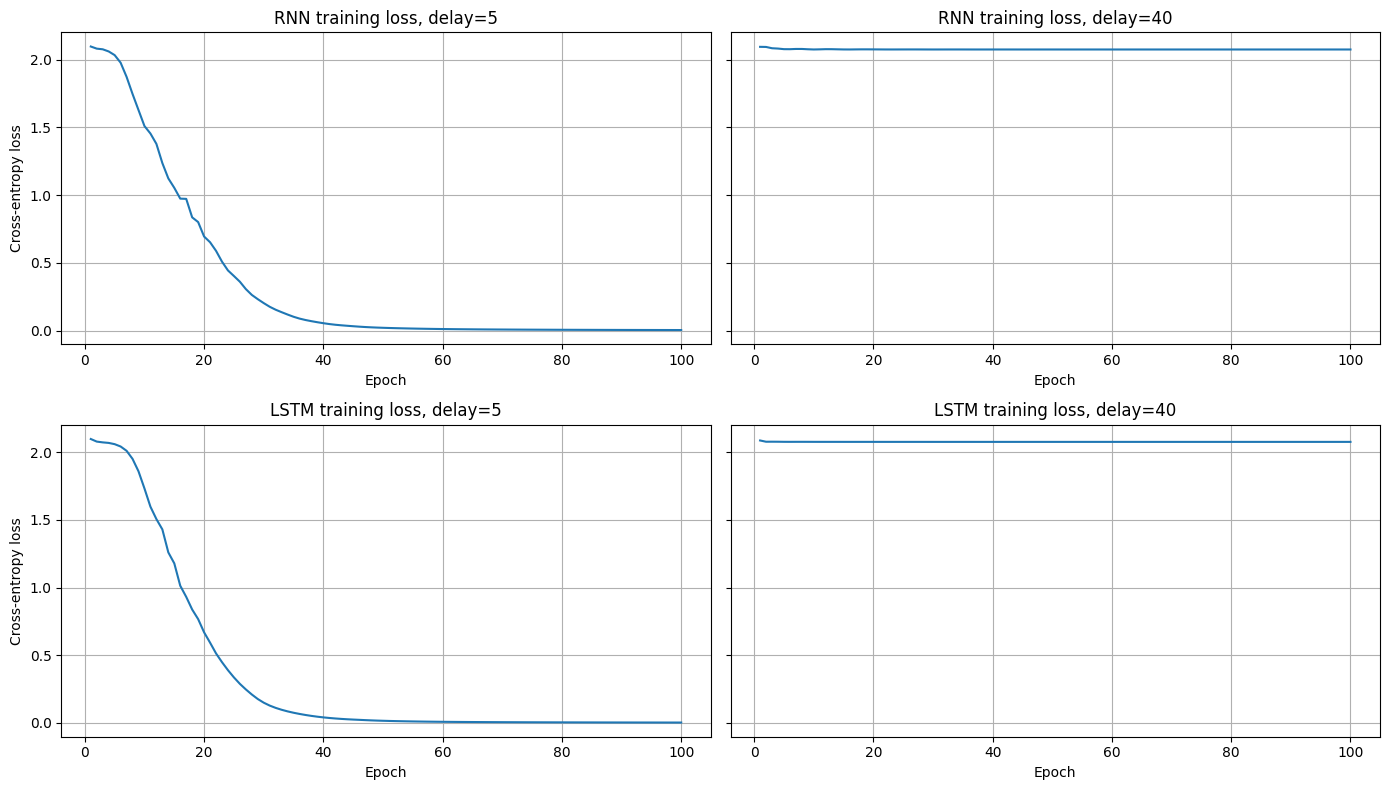

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey='row')

epochs = np.arange(1, n_epochs + 1)

axes[0, 0].plot(epochs, train_loss_short)
axes[0, 0].set_title(f'RNN training loss, delay={delay_short}')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Cross-entropy loss')

axes[0, 1].plot(epochs, train_loss_long)
axes[0, 1].set_title(f'RNN training loss, delay={delay_long}')
axes[0, 1].set_xlabel('Epoch')

axes[1, 0].plot(epochs, train_loss_short_lstm)
axes[1, 0].set_title(f'LSTM training loss, delay={delay_short}')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Cross-entropy loss')

axes[1, 1].plot(epochs, train_loss_long_lstm)
axes[1, 1].set_title(f'LSTM training loss, delay={delay_long}')
axes[1, 1].set_xlabel('Epoch')

plt.tight_layout()
plt.show()


## **Exercise 2.** Does the Forget Gate Bias Matter?

One of the key innovations of the LSTM is the **forget gate**, which controls how much information is retained in the cell state from one timestep to the next.

In the `reset_parameters()` function, all gate biases are currently initialised with small random values. This means that, at the start of training, the forget gate has no particular preference for remembering information over long sequences.

### Your task:

Identify and modify the part of the code that specifies the initialisation of the **forget gate bias** (`f` gate).  and investigate how it affects performance on the **long copy task** (`delay = 40`).

1. What is the current value of the initialisation of the forget gate bias?
2. Which function needs to be modified? How is initialisation currently performed? **ANSWER:** Locate the `reset_parameters` method of `ScratchLSTM`.  Currently everything is randomly initialised.
3. Repeat Exercise 1 using different bias initialisation values, for example:
   * 0.0
   * 0.5
   * 1.0
   * 2.0

**Hint:** The LSTM gates are stored in the order **input (`i`), forget (`f`), candidate (`g`), output (`o`)**. Therefore, the forget gate occupies the second block of `hidden_size` elements in the bias vector.
**ANSWER:** After the random initialization of `bias_ih`, set the forget gate bias to a constant value.

**Discussion:** Which initialisation produces the best performance?


## **Exercise 3:** Inference on unseen delays

In this section we freeze the trained RNN and LSTM (long and short delay) and evaluate it on copy-task examples with different delay lengths.

1. Evaluate the trained models on delays 5, 10, 20, and 40.
2. Plot the accuracy (i.e. percentage of correct predictions)
3. Explain your observations.

**ANSWER:** The short delay LSTM works best, beating the short delay RNN.  The LSTM was able to learn the underlying algorithm, rather that learning the task for a fixed delay.  This is rather interesting, given that the training data was all of the same delay.  Somewhat counterintuitively, the long delay models perform worse. The reason for this is because the models haven't learned the rule properly yet (as evidenced by the poor training loss). To improve on this, we could use a curriculum, i.e. training data that has a variety of delays and with training performed on batches with increasing delay.  

In [ ]:
# Generate fixed unseen test data for each delay we want to evaluate.
eval_delays = [5, 10, 20, 40]
n_inference_test = n_test

unseen_test_sets = {}
for delay in eval_delays:
    X_test_delay, y_test_delay = generate_memory_task(
        n_samples=n_inference_test,
        delay=delay,
        vocab_size=vocab_size,
        seed=99 + delay
    )
    unseen_test_sets[delay] = (X_test_delay, y_test_delay)

# Sanity check: each sequence has length delay + 2
for delay, (X_test_delay, y_test_delay) in unseen_test_sets.items():
    print(f'Delay {delay:2d}: X shape = {tuple(X_test_delay.shape)}, y shape = {tuple(y_test_delay.shape)}')

Delay  5: X shape = (200, 7), y shape = (200,)
Delay 10: X shape = (200, 12), y shape = (200,)
Delay 20: X shape = (200, 22), y shape = (200,)
Delay 40: X shape = (200, 42), y shape = (200,)


In [ ]:
def accuracy_by_delay(model, test_sets, delays, device='cpu'):
    model.eval()
    accuracies = []

    for delay in delays:
        X_test, y_test = test_sets[delay]
        X_test = X_test.to(device)
        y_test = y_test.to(device)

        with torch.no_grad():
            logits = model(X_test)  # Run model on test inputs
            preds = logits.argmax(dim=1)  # Pick predicted class
            acc = (preds == y_test).float().mean().item() # Compute accuracy (float converts boolean to numbers and mean computes average and item converts to ordinary python float)

        accuracies.append(acc)

    return accuracies

In [ ]:
comparison_models = {
    f'RNN short trained (delay={delay_short})': model_short,
    f'RNN long trained (delay={delay_long})': model_long,
    f'LSTM short trained (delay={delay_short})': lstm_model_short,
    f'LSTM long trained (delay={delay_long})': lstm_model_long,
}

comparison_accuracies = {}
for name, mdl in comparison_models.items():
    comparison_accuracies[name] = accuracy_by_delay(
        model=mdl,
        test_sets=unseen_test_sets,
        delays=eval_delays,
        device='cpu'
    )

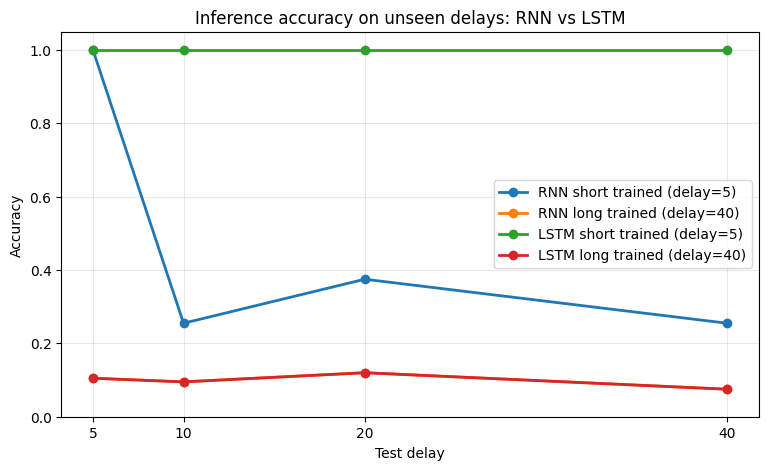

In [ ]:
plt.figure(figsize=(9, 5))

for name, accs in comparison_accuracies.items():
    plt.plot(eval_delays, accs, marker='o', linewidth=2, label=name)

plt.xlabel('Test delay')
plt.ylabel('Accuracy')
plt.title('Inference accuracy on unseen delays: RNN vs LSTM')
plt.xticks(eval_delays)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## **Exercise 3: Inspect Gradient Flow for RNN and LSTM**

Plot the hidden-state gradient norms for `model_short` and `model_long` on a log scale.  Overlay the RNN and LSTM curves on the same plot so you can compare how quickly gradients decay through time for the two recurrent architectures.

Line-plot diagnostic losses:
  RNN short: 0.0049
  RNN long : 2.0791
  LSTM short: 0.0031
  LSTM long : 2.0791


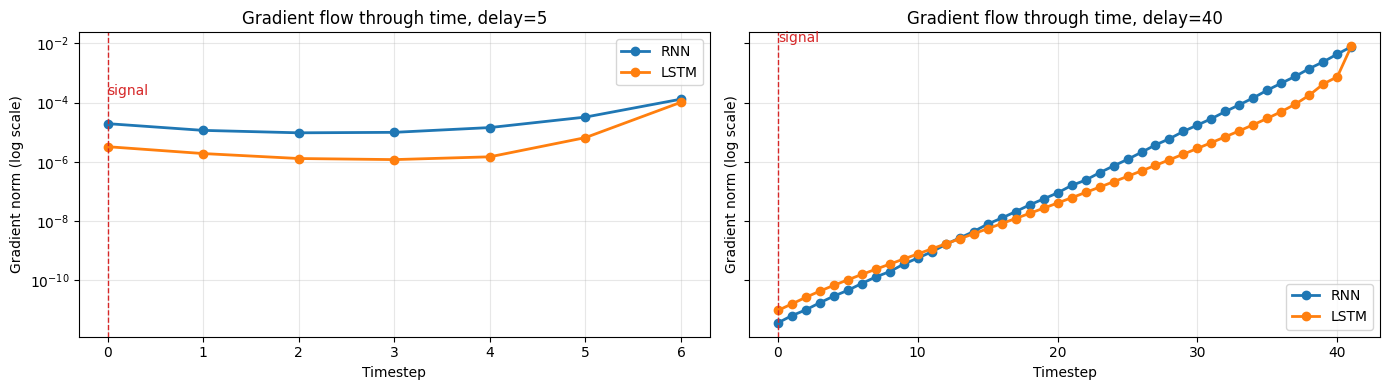

In [ ]:
def measure_gradient_flow_lineplot(model, X, y):
    # Return the gradient norm at each timestep for a single forward/backward pass.
    model.eval()
    model.zero_grad(set_to_none=True)

    logits, hiddens = model(X, return_hiddens=True)
    loss = nn.CrossEntropyLoss()(logits, y)
    loss.backward() #run backward pass and store gradients.

    norms = []
    for h_t in hiddens:
        if h_t.grad is None:
            norms.append(0.0)
        else:
            # Average over batch so the plot is easy to read in class.
            norms.append(h_t.grad.norm(dim=1).mean().item())

    return norms, loss.item()

line_norms_rnn_short, line_loss_rnn_short = measure_gradient_flow_lineplot(
    model_short, X_short_test[:64], y_short_test[:64])

line_norms_rnn_long, line_loss_rnn_long = measure_gradient_flow_lineplot(
    model_long, X_long_test[:64], y_long_test[:64])

line_norms_lstm_short, line_loss_lstm_short = measure_gradient_flow_lineplot(
    lstm_model_short, X_short_test[:64], y_short_test[:64])

line_norms_lstm_long, line_loss_lstm_long = measure_gradient_flow_lineplot(
    lstm_model_long, X_long_test[:64], y_long_test[:64])


print('Line-plot diagnostic losses:')
print('  RNN short:', round(line_loss_rnn_short, 4))
print('  RNN long :', round(line_loss_rnn_long, 4))
print('  LSTM short:', round(line_loss_lstm_short, 4))
print('  LSTM long :', round(line_loss_lstm_long, 4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, rnn_norms, lstm_norms, title in [
    (axes[0], line_norms_rnn_short, line_norms_lstm_short, f'Gradient flow through time, delay={delay_short}'),
    (axes[1], line_norms_rnn_long, line_norms_lstm_long, f'Gradient flow through time, delay={delay_long}'),
]:
    t = np.arange(len(rnn_norms))
    ax.plot(t, np.maximum(rnn_norms, 1e-12), marker='o', linewidth=2, label='RNN')
    ax.plot(t, np.maximum(lstm_norms, 1e-12), marker='o', linewidth=2, label='LSTM')
    ax.set_yscale('log')
    ax.set_title(title)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Gradient norm (log scale)')
    ax.axvline(0, color='tab:red', linestyle='--', linewidth=1)
    ax.text(0, max(np.maximum(rnn_norms, 1e-12).max(), np.maximum(lstm_norms, 1e-12).max()) * 1.1,
            'signal', color='tab:red', ha='left', va='bottom')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


**IMPORTANT:** The above plots should be read from right to left, as it's plotting the gradients in the backward pass. You should not focus on the absolute value of the gradient, but the relative differences. In the long delay setting, we see gradients reduce at T=0 by a factor of about 10^8 compared to T = 40.  This relative difference is an indicator of vanishing gradients.

## **Exercise 4: Curriculum based training**

In the below, we will repeat training of the RNN and LSTM but this time using training data that includes a range of delays. The model is first trained on short delays, then progressively trained on longer delays.

Evaluate the below cells (you do not need to code anything).  What do you observe?

In [ ]:
def train_model_curriculum(
    model,
    curriculum_delays,
    n_train,
    n_test,
    vocab_size,
    task_name,
    epochs_per_stage=30,
    lr=0.01,
    device="cpu",
    seed=42
):

    #Train a model using curriculum learning.

    #The model is first trained on short delays, then progressively trained
    #on longer delays. The same model parameters are carried forward from
    #one stage to the next.

    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    stage_test_accs = []

    for stage_idx, delay in enumerate(curriculum_delays):
        print(f"\n{task_name}: curriculum stage {stage_idx + 1}/{len(curriculum_delays)}")
        print(f"Training on delay = {delay}")

        # Fixed test set for this stage
        X_test, y_test = generate_memory_task(
            n_samples=n_test,
            delay=delay,
            vocab_size=vocab_size,
            seed=seed + 1000 + delay
        )
        X_test = X_test.to(device)
        y_test = y_test.to(device)

        for epoch in range(epochs_per_stage):
            model.train()

            # Fresh training batch each epoch at the current delay
            X_train, y_train = generate_memory_task(
                n_samples=n_train,
                delay=delay,
                vocab_size=vocab_size,
                seed=None
            )
            X_train = X_train.to(device)
            y_train = y_train.to(device)

            logits = model(X_train)
            loss = criterion(logits, y_train)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

            if (epoch + 1) % 10 == 0:
                model.eval()
                with torch.no_grad():
                    test_logits = model(X_test)
                    preds = test_logits.argmax(dim=1)
                    acc = (preds == y_test).float().mean().item()

                print(
                    f"  epoch {epoch + 1:02d}/{epochs_per_stage}, "
                    f"loss={loss.item():.4f}, "
                    f"stage test acc={acc:.3f}"
                )

        # Final accuracy for this curriculum stage
        model.eval()
        with torch.no_grad():
            test_logits = model(X_test)
            preds = test_logits.argmax(dim=1)
            stage_acc = (preds == y_test).float().mean().item()

        stage_test_accs.append(stage_acc)

    print(f"\nFinished curriculum training for {task_name}")
    return train_losses, stage_test_accs

In [ ]:
curriculum_delays = [5, 10, 20, 40]
epochs_per_stage = 30

rnn_model_curriculum = SimpleRNN(
    vocab_size,
    embed_dim,
    hidden_size,
    n_classes
)

lstm_model_curriculum = LSTMModel(
    vocab_size,
    embed_dim,
    hidden_size,
    n_classes
)

rnn_curriculum_losses, rnn_curriculum_stage_accs = train_model_curriculum(
    model=rnn_model_curriculum,
    curriculum_delays=curriculum_delays,
    n_train=n_train,
    n_test=n_test,
    vocab_size=vocab_size,
    task_name="RNN curriculum",
    epochs_per_stage=epochs_per_stage,
    lr=lr,
    device="cpu"
)

lstm_curriculum_losses, lstm_curriculum_stage_accs = train_model_curriculum(
    model=lstm_model_curriculum,
    curriculum_delays=curriculum_delays,
    n_train=n_train,
    n_test=n_test,
    vocab_size=vocab_size,
    task_name="LSTM curriculum",
    epochs_per_stage=epochs_per_stage,
    lr=lr,
    device="cpu"
)


RNN curriculum: curriculum stage 1/4
Training on delay = 5
  epoch 10/30, loss=2.0251, stage test acc=0.395
  epoch 20/30, loss=0.9607, stage test acc=0.850
  epoch 30/30, loss=0.1720, stage test acc=1.000

RNN curriculum: curriculum stage 2/4
Training on delay = 10
  epoch 10/30, loss=0.0313, stage test acc=1.000
  epoch 20/30, loss=0.0107, stage test acc=1.000
  epoch 30/30, loss=0.0061, stage test acc=1.000

RNN curriculum: curriculum stage 3/4
Training on delay = 20
  epoch 10/30, loss=0.0062, stage test acc=1.000
  epoch 20/30, loss=0.0046, stage test acc=1.000
  epoch 30/30, loss=0.0035, stage test acc=1.000

RNN curriculum: curriculum stage 4/4
Training on delay = 40
  epoch 10/30, loss=2.8108, stage test acc=0.415
  epoch 20/30, loss=3.7894, stage test acc=0.115
  epoch 30/30, loss=2.2963, stage test acc=0.120

Finished curriculum training for RNN curriculum

LSTM curriculum: curriculum stage 1/4
Training on delay = 5
  epoch 10/30, loss=1.8062, stage test acc=0.465
  epoch 20

In [ ]:
eval_delays = [5, 10, 20, 40]
n_inference_test = n_test

unseen_test_sets = {}

for delay in eval_delays:
    X_test_delay, y_test_delay = generate_memory_task(
        n_samples=n_inference_test,
        delay=delay,
        vocab_size=vocab_size,
        seed=99 + delay
    )
    unseen_test_sets[delay] = (X_test_delay, y_test_delay)

In [ ]:
def accuracy_by_delay_cur(model, test_sets, delays, device="cpu"):
    model.eval()
    accuracies = []

    for delay in delays:
        X_test, y_test = test_sets[delay]
        X_test = X_test.to(device)
        y_test = y_test.to(device)

        with torch.no_grad():
            logits = model(X_test)
            preds = logits.argmax(dim=1)
            acc = (preds == y_test).float().mean().item()

        accuracies.append(acc)

    return accuracies

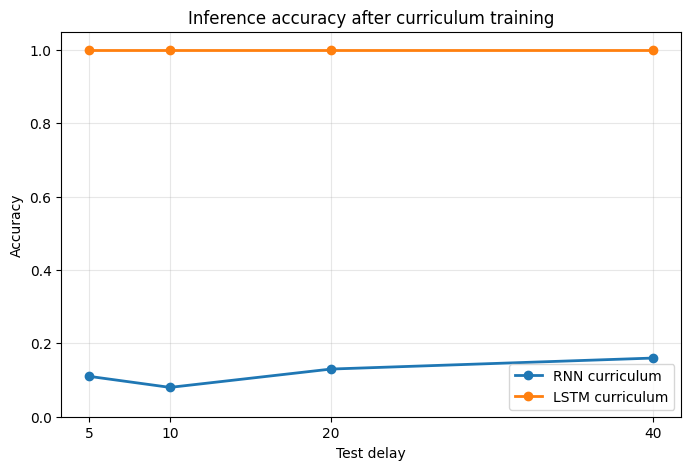

In [ ]:
comparison_models = {
    "RNN curriculum": rnn_model_curriculum,
    "LSTM curriculum": lstm_model_curriculum,
}

comparison_accuracies = {}

for name, mdl in comparison_models.items():
    comparison_accuracies[name] = accuracy_by_delay_cur(
        model=mdl,
        test_sets=unseen_test_sets,
        delays=eval_delays,
        device="cpu"
    )

plt.figure(figsize=(8, 5))

for name, accs in comparison_accuracies.items():
    plt.plot(eval_delays, accs, marker="o", linewidth=2, label=name)

plt.xlabel("Test delay")
plt.ylabel("Accuracy")
plt.title("Inference accuracy after curriculum training")
plt.xticks(eval_delays)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()